In [1]:
from snc_sf.selection_function import SNCSelectionFunction
import matplotlib.pylab as plt
import os
import numpy as np
import polars as pl
%matplotlib inline
plt.style.use('%s/mystyle.mplstyle' % os.environ['MPL_STYLES'])


sncsf = SNCSelectionFunction('../../obs_100pc_dr19.csv')
sncsf.sample_posterior(1000)

/Users/imedan/Desktop/VU_PostDoc_Research/SDSS_V/selection_function/snc_sf/src/snc_sf/utils.py:135: RuntimeWarning: invalid value encountered in log10
  MG = phot_g_mean_mag + 5 * np.log10(1e-3 * parallax) + 5


In [2]:
def lum_func(weights, G, plx, plx_err, MG_lum):
    MG = G + 5 * np.log10(1e-3 * np.random.normal(plx, plx_err)) + 5
    N, _ = np.histogram(MG, weights=weights, bins=MG_lum)
    N /=  (MG_lum[1] - MG_lum[0])
    return N


# create filter expresion
# This removes faint sources and white dwarfs from the sample
MG = sncsf.data['phot_g_mean_mag'] + 5 * np.log10(1e-3 * sncsf.data['parallax']) + 5
filt = (pl.col("phot_g_mean_mag") < 20)  & (MG < 10 * sncsf.data['g_rp'] + 5)

# data to be passed to lum_func
# This is an Polars expression that is MG in lum_func()
data_expr = [(pl.col('phot_g_mean_mag')),
             (pl.col('parallax')),
             (pl.col('parallax_error'))]

# bins for the lum_func
# This will be passed as the final argument in lum_func()
MG_lum = np.linspace(2.5, 22.5, 75)
args = [MG_lum]

N_boot = sncsf.bootstrap_values(lum_func, filt, data_expr, args)


/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_40369/497055756.py:2: RuntimeWarning: invalid value encountered in log10
  MG = G + 5 * np.log10(1e-3 * np.random.normal(plx, plx_err)) + 5


In [3]:
MG_data = sncsf.data.select(MG).filter(filt).to_numpy().reshape((-1, ))

N, _ = np.histogram(MG_data, weights=np.zeros(len(MG_data)) + 1 / (4/3 * np.pi * 100 ** 3), bins=MG_lum)
N /=  (MG_lum[1] - MG_lum[0])


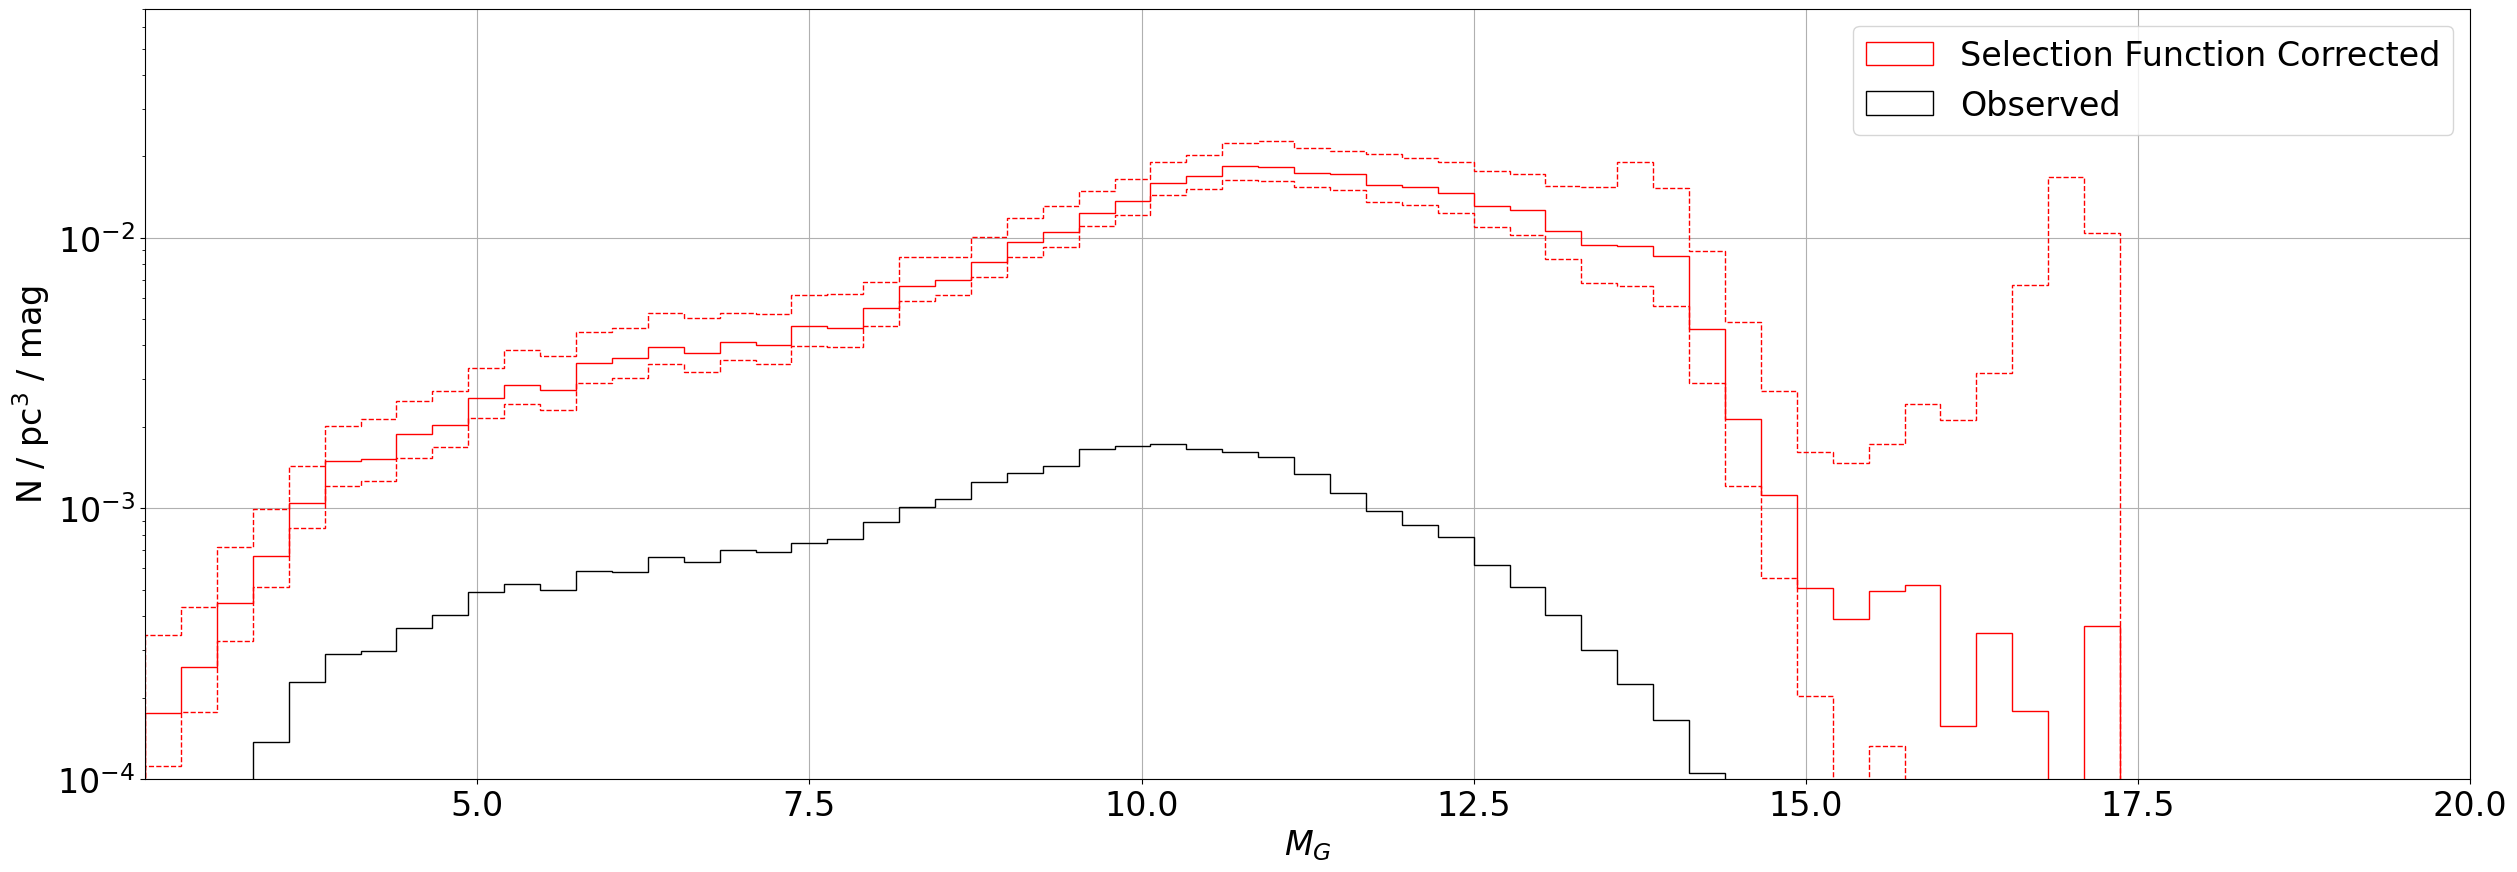

In [4]:
plt.figure(figsize=(30, 10))

plt.hist(MG_lum[:-1], bins=MG_lum, weights=np.nanmedian(N_boot, axis=0), label='Selection Function Corrected',
        histtype='step', lw=2, edgecolor='r')
plt.hist(MG_lum[:-1], bins=MG_lum,
         weights=np.nanpercentile(N_boot, 2.5, axis=0),
         label=None,
        histtype='step', lw=1, linestyle='--', edgecolor='r')
plt.hist(MG_lum[:-1], bins=MG_lum,
         weights=np.nanpercentile(N_boot, 97.5, axis=0),
         label=None,
        histtype='step', lw=1, linestyle='--', edgecolor='r')

plt.hist(MG_lum[:-1], bins=MG_lum, weights=N, label='Observed',
        histtype='step', lw=2, edgecolor='k')

plt.xticks(np.arange(5, 22.5, 2.5))

plt.grid()
plt.xlim((2.5, 20))
plt.ylim((1e-4, 7e-2))
plt.yscale('log')
plt.xlabel(r'$M_G$')
plt.ylabel(r'N / pc$^3$ / mag')
plt.legend()
plt.savefig('paper_plots/luminosity_func.png', bbox_inches='tight')
plt.show()




In [5]:
truth = {}
truth['RECONS'] = [['k', '^'],
                   [2-0.03, 0.0105, 0.0016],
                   [3-0.03, 0.0676, 0.0040]]

truth['EMM'] = [['b', '*'],
                [0-0.02, 0.0024, 0.0003]]

truth['Mamajek+08'] = [['y', 's'],
                       [1-0.01, 0.0033, 0.0004]]

truth['Kirkpatrick+12'] = [['m', 'D'],
                           [1+0.01, 0.0037, 0.0013],
                           [2+0.01, 0.0135, 0.0025],
                           [3+0.01, 0.0859, 0.0086]]

truth['Winters+19'] = [['c', 'P'],
                       [3+0.02, 0.0917, 0.0132]]






In [6]:
def num_density(weights):
    return np.nansum(weights)

MG_cuts = [[2.51, 4.325],
           [4.325, 5.553],
           [5.553, 8.10 ],
           [8.10, 16.60]]


labels = ['F Dwarfs', 'G Dwarfs', 'K Dwarfs', 'M Dwarfs']

num_dens_all = np.zeros((len(MG_cuts), 3))

MG = sncsf.data['phot_g_mean_mag'] + 5 * np.log10(1e-3 * sncsf.data['parallax']) + 5

for it in range(len(MG_cuts)):
    filt = (pl.col("phot_g_mean_mag") < 20) &\
           (MG > MG_cuts[it][0]) & (MG < MG_cuts[it][1]) & (MG < 10 * sncsf.data['g_rp'] + 5)
    num_dens = sncsf.bootstrap_values(num_density, filt)
    num_dens_all[it] = np.nanpercentile(num_dens, [2.5, 50, 97.5])




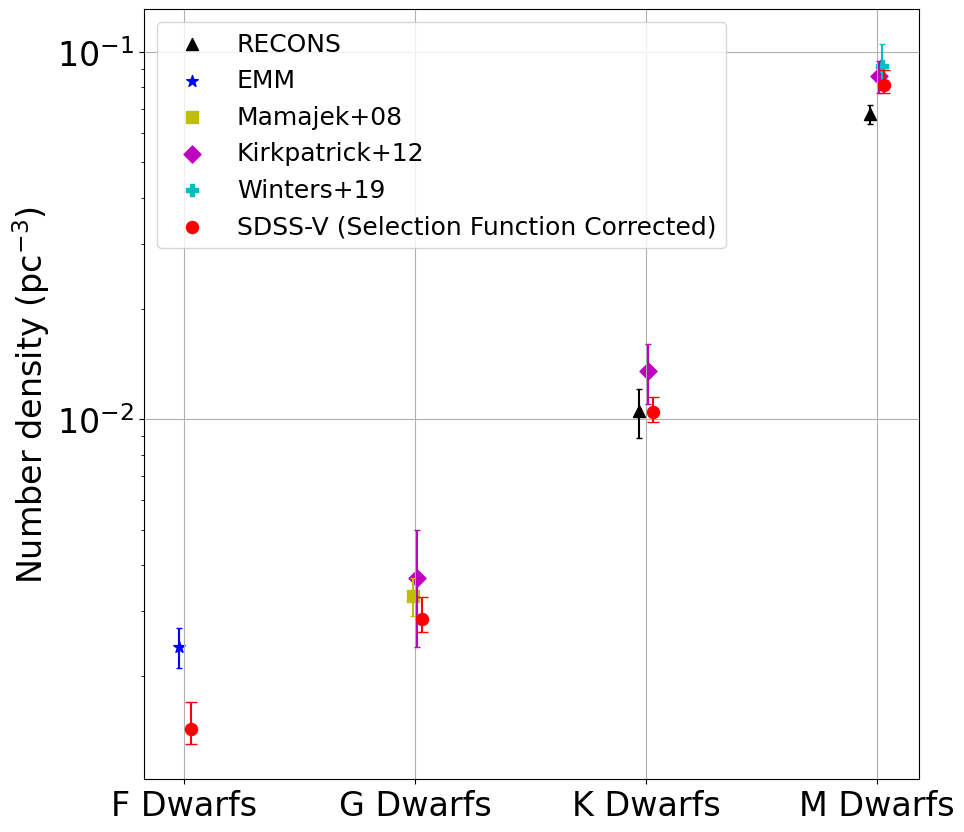

In [7]:
plt.figure(figsize=(10, 10))

for k in truth.keys():
    label = k
    c = truth[k][0][0]
    marker = truth[k][0][1]
    data = np.array(truth[k][1:])
    # rand = np.random.normal(0, 0.01, len(data[:, 0]))
    plt.scatter(data[:, 0], data[:, 1], c=c, label=label, marker=marker, s=75)
    plt.errorbar(data[:, 0], data[:, 1], yerr=data[:, 2],
                 fmt='none', ecolor=c)

plt.scatter(np.arange(len(MG_cuts))+0.03, num_dens_all[:, 1], c='r', label='SDSS-V (Selection Function Corrected)',
            zorder=9999, s=75)
plt.errorbar(np.arange(len(MG_cuts))+0.03, num_dens_all[:, 1], yerr=np.diff(num_dens_all).T,
             fmt='none', ecolor='r', capsize=4)

plt.grid()
plt.yscale('log')
plt.ylabel(r'Number density (pc$^{-3}$)')
plt.legend(ncol=1, prop={'size': 18})
# plt.ylim(1e-3, 1e0)
plt.xticks(np.arange(len(MG_cuts)), labels)
plt.savefig('paper_plots/number_density.png', bbox_inches='tight')
plt.show()




In [8]:
def HR_diagram(weights, G_RP, MG, G_RPbins, MG_bins):
    N, _, _ = np.histogram2d(G_RP, MG,
                             weights=weights, bins=[G_RPbins, MG_bins])
    mag2 = (G_RPbins[1] - G_RPbins[0]) * (MG_bins[1] - MG_bins[0])
    N /= mag2
    return N

filt = (pl.col("phot_g_mean_mag") < 20)

data_expr = [(pl.col('g_rp')),
             (pl.col('phot_g_mean_mag') + 5 * np.log10(1e-3 * pl.col('parallax')) + 5)]

Nbin = 100
G_RPbins = np.linspace(-0.5, 2.15, Nbin)
MG_bins = np.linspace(0, 20, Nbin)
args = [G_RPbins, MG_bins]

N_boot = sncsf.bootstrap_values(HR_diagram, filt, data_expr, args)


In [9]:
GRP_data = sncsf.data.filter(filt)['g_rp'].to_numpy().reshape((-1, ))
MG_data = sncsf.data.filter(filt).select(data_expr[1]).to_numpy().reshape((-1, ))

N = HR_diagram(np.zeros(len(MG_data)) + 1 / (4/3 * np.pi * 100 ** 3),
               GRP_data, MG_data, G_RPbins, MG_bins)

/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_40369/756840161.py:23: RuntimeWarning: divide by zero encountered in divide
  dens = ax3.imshow(N.T / np.nanmedian(N_boot, axis=0).T, origin='lower',
/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_40369/756840161.py:23: RuntimeWarning: invalid value encountered in divide
  dens = ax3.imshow(N.T / np.nanmedian(N_boot, axis=0).T, origin='lower',


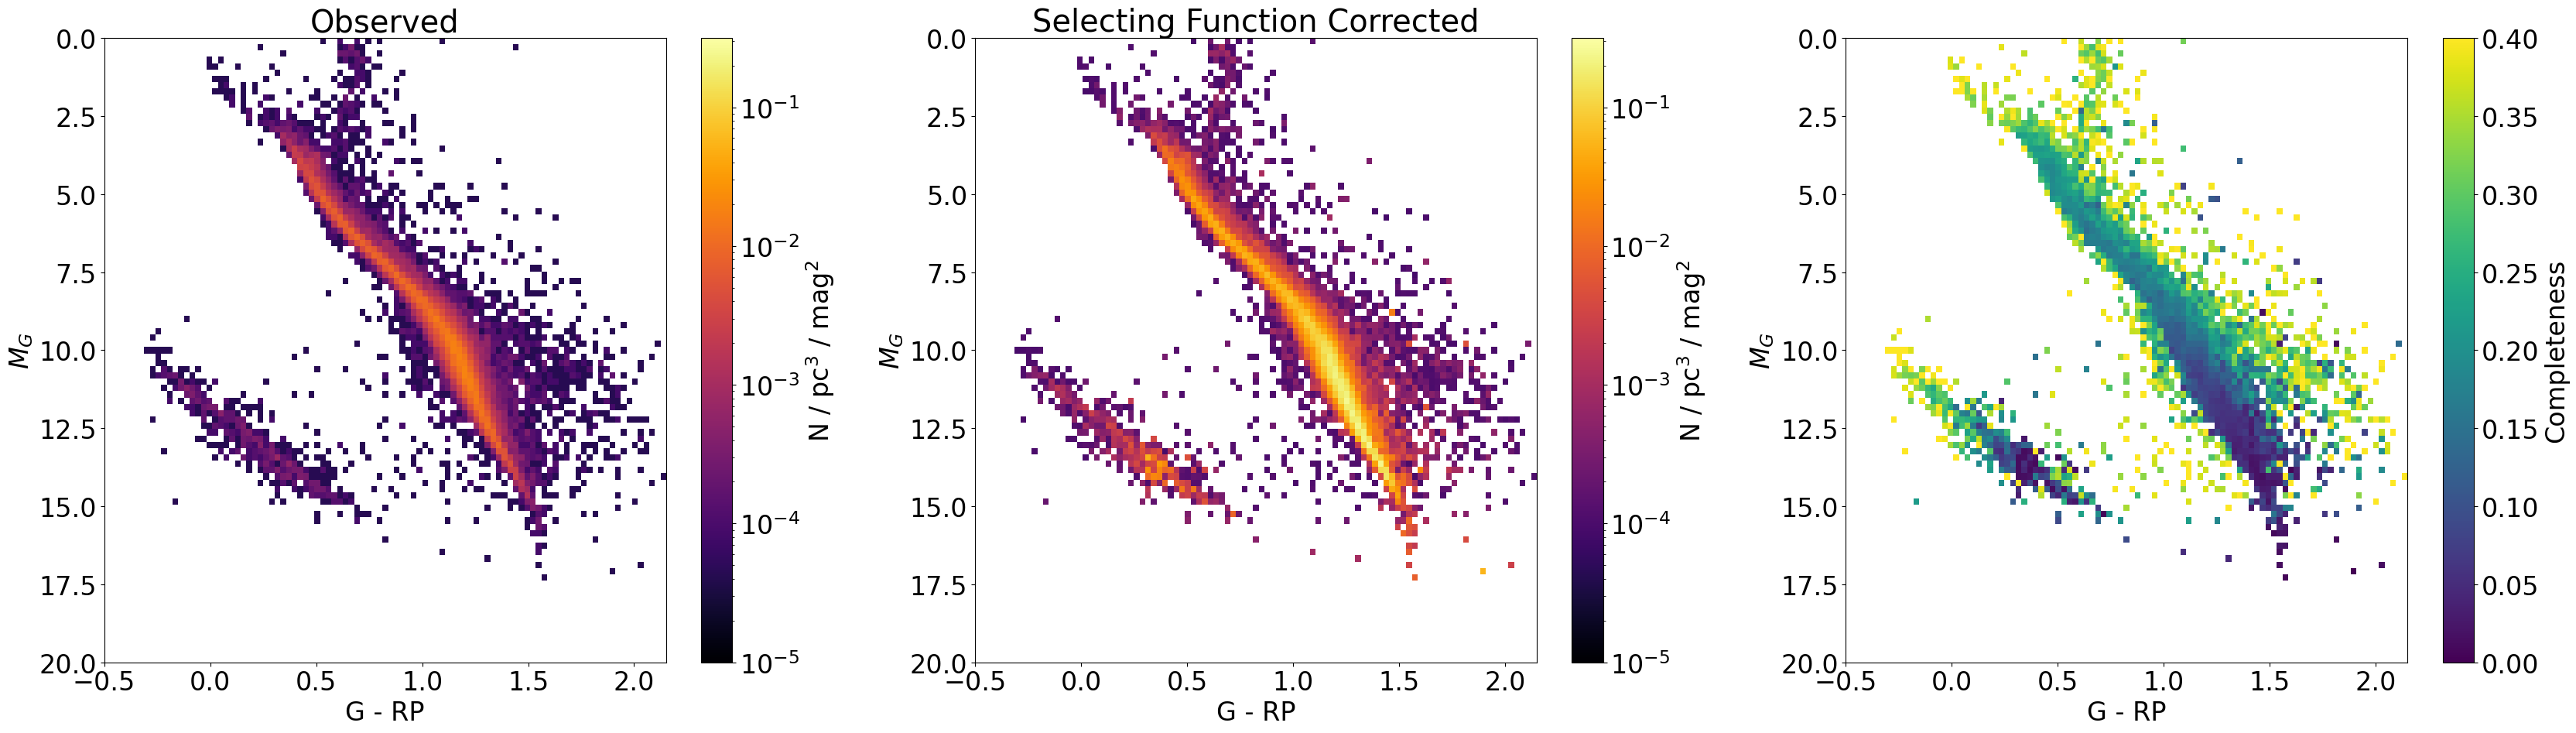

In [10]:
from matplotlib.colors import LogNorm

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(34, 10))

dens = ax1.imshow(N.T, origin='lower',
                  extent=(G_RPbins.min(), G_RPbins.max(), MG_bins.min(), MG_bins.max()),
                   aspect='auto', cmap='inferno', norm=LogNorm(1e-5, 10 ** -0.5))
ax1.invert_yaxis()
plt.colorbar(dens, ax=ax1, label=r'N / pc$^3$ / mag$^2$')
ax1.set_title('Observed')
ax1.set_xlabel('G - RP')
ax1.set_ylabel(r'$M_G$')

dens = ax2.imshow(np.nanmedian(N_boot, axis=0).T, origin='lower',
                  extent=(G_RPbins.min(), G_RPbins.max(), MG_bins.min(), MG_bins.max()),
                   aspect='auto', cmap='inferno', norm=LogNorm(1e-5, 10 ** -0.5))
ax2.invert_yaxis()
plt.colorbar(dens, ax=ax2, label=r'N / pc$^3$ / mag$^2$')
ax2.set_title('Selecting Function Corrected')
ax2.set_xlabel('G - RP')
ax2.set_ylabel(r'$M_G$')

dens = ax3.imshow(N.T / np.nanmedian(N_boot, axis=0).T, origin='lower',
                  extent=(G_RPbins.min(), G_RPbins.max(), MG_bins.min(), MG_bins.max()),
                   aspect='auto', cmap='viridis', vmin=0, vmax=0.4)
ax3.invert_yaxis()
plt.colorbar(dens, ax=ax3, label=r'Completeness')
ax3.set_xlabel('G - RP')
ax3.set_ylabel(r'$M_G$')
plt.tight_layout()
plt.savefig('paper_plots/HR_diagram.png', bbox_inches='tight')
plt.show()


In [11]:
wdsf = SNCSelectionFunction('../../obs_100pc_wd_dr19.csv')
wdsf.sample_posterior(1000)


In [12]:
def HR_diagram(weights, G_RP, MG, G_RPbins, MG_bins):
    N, _, _ = np.histogram2d(G_RP, MG,
                             weights=weights, bins=[G_RPbins, MG_bins])
    mag2 = (G_RPbins[1] - G_RPbins[0]) * (MG_bins[1] - MG_bins[0])
    N /= mag2
    return N

filt = (pl.col("phot_g_mean_mag") < 20)

data_expr = [(pl.col('phot_bp_mean_mag') - pl.col('phot_rp_mean_mag')),
             (pl.col('phot_g_mean_mag') + 5 * np.log10(1e-3 * pl.col('parallax')) + 5)]

Nbin = 75
G_RPbins = np.linspace(-0.6, 1.7, Nbin)
MG_bins = np.linspace(5, 17, Nbin)
args = [G_RPbins, MG_bins]

N_boot = wdsf.bootstrap_values(HR_diagram, filt, data_expr, args)




In [13]:
GRP_data = wdsf.data.filter(filt).select(data_expr[0]).to_numpy().reshape((-1, ))
MG_data = wdsf.data.filter(filt).select(data_expr[1]).to_numpy().reshape((-1, ))

N = HR_diagram(np.zeros(len(MG_data)) + 1 / (4/3 * np.pi * 100 ** 3),
               GRP_data, MG_data, G_RPbins, MG_bins)


/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_40369/1277820690.py:3: RuntimeWarning: divide by zero encountered in log10
  dens = ax1.imshow(np.log10(N.T), origin='lower',
/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_40369/1277820690.py:12: RuntimeWarning: divide by zero encountered in log10
  dens = ax2.imshow(np.log10(np.nanmedian(N_boot, axis=0).T), origin='lower',


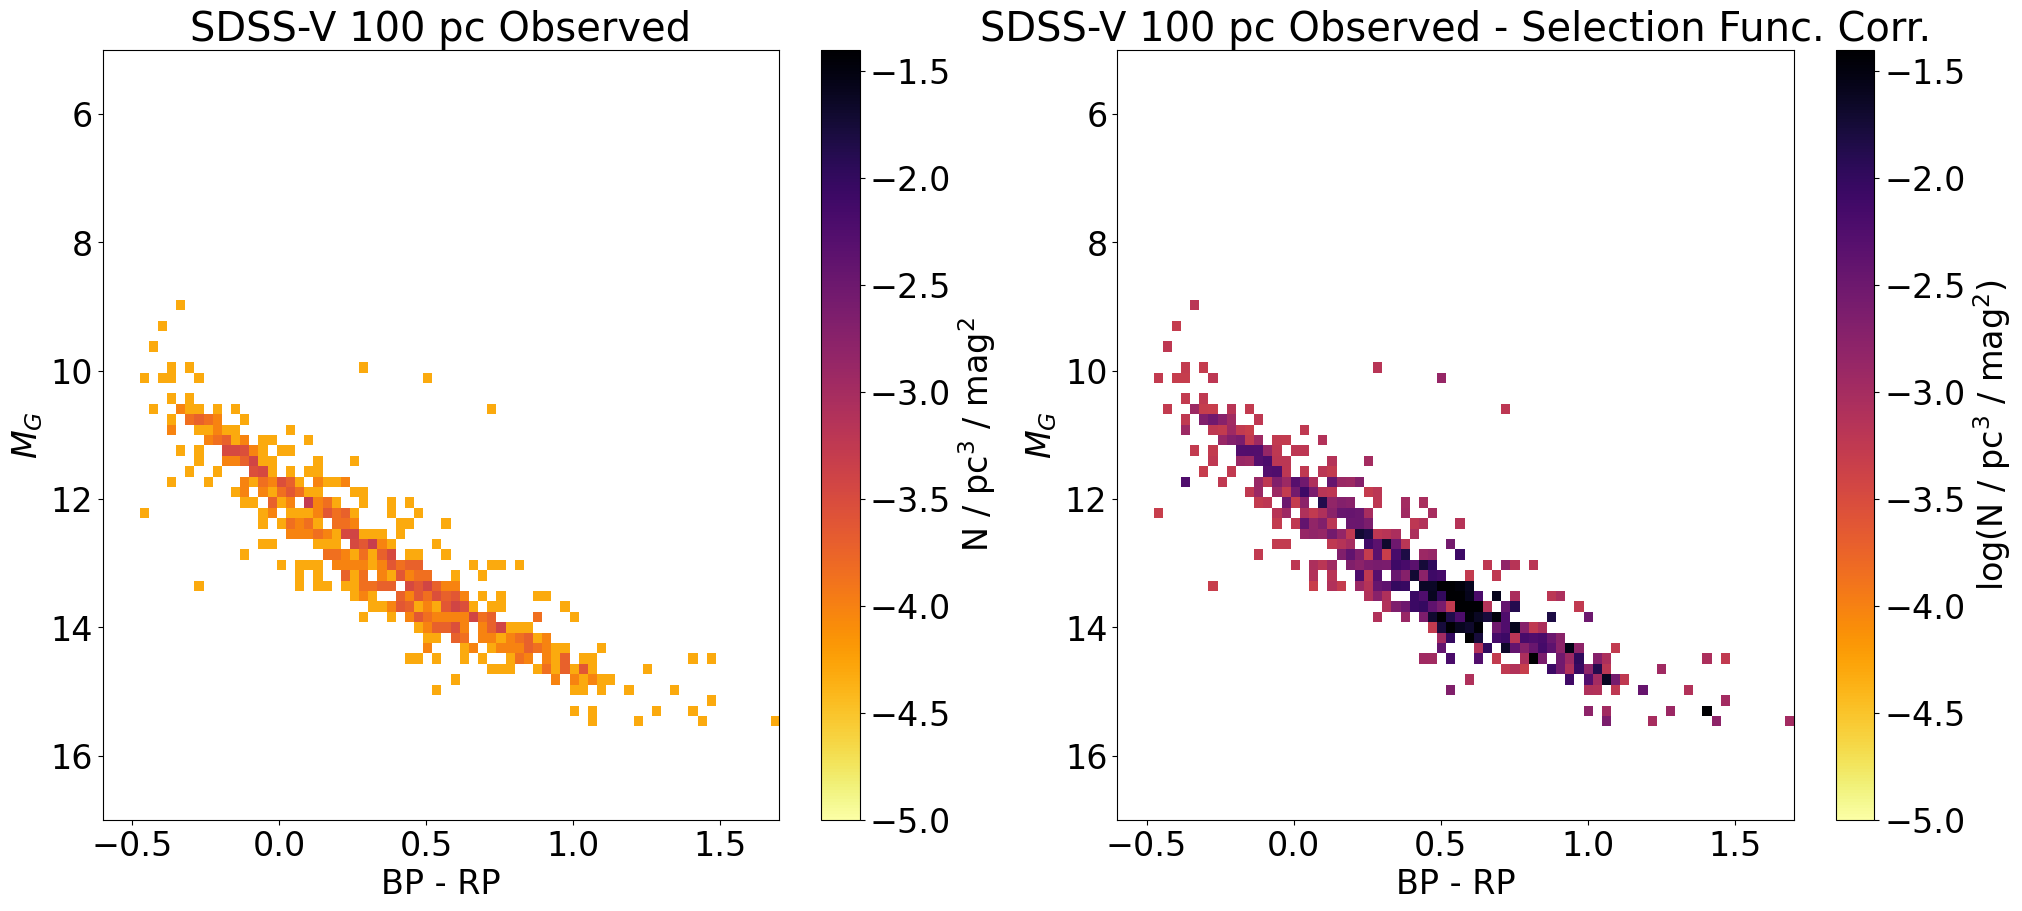

In [14]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

dens = ax1.imshow(np.log10(N.T), origin='lower',
                  extent=(G_RPbins.min(), G_RPbins.max(), MG_bins.min(), MG_bins.max()),
                   aspect='auto', cmap='inferno_r', vmin=-5, vmax=-1.4)
ax1.invert_yaxis()
plt.colorbar(dens, ax=ax1, label=r'N / pc$^3$ / mag$^2$')
ax1.set_title('SDSS-V 100 pc Observed')
ax1.set_xlabel('BP - RP')
ax1.set_ylabel(r'$M_G$')

dens = ax2.imshow(np.log10(np.nanmedian(N_boot, axis=0).T), origin='lower',
                  extent=(G_RPbins.min(), G_RPbins.max(), MG_bins.min(), MG_bins.max()),
                   aspect='auto', cmap='inferno_r', vmin=-5, vmax=-1.4)
ax2.invert_yaxis()
plt.colorbar(dens, ax=ax2, label=r'log(N / pc$^3$ / mag$^2$)')
ax2.set_title('SDSS-V 100 pc Observed - Selection Func. Corr.')
ax2.set_xlabel('BP - RP')
ax2.set_ylabel(r'$M_G$')

plt.show()
